# Grammar Confidence / Internal Representation Experiment

このノートブックは、**指示文の違いが LLM の出力精度と内部表現にどう影響するか**を調べるための軽量実験用です。

比較する条件は次の2つです。

- **A**: 「以下の英文章には文法的な間違いがあります。それを修正してください。」
- **B**: 「以下の英文章には文法的な間違いがあれば、それを修正してください。」

狙いは以下の2点です。

1. **出力差**  
   - 誤文に対して正しく修正できるか
   - 正しい文を不必要に直してしまわないか
   - 応答がどれくらい断定的 / 保留的か

2. **内部表現差**  
   - プロンプト入力時の hidden state が  
     **「修正モード」** / **「保留モード」** / **「高確信」** / **「低確信」**  
     のどちら寄りにあるか
   - その差が層ごとにどう出るか

元ノートブックの構成（`transformers` / `SentenceTransformer` / hidden states / 層別コサイン類似度）に寄せてあります。


In [ ]:
# Cell 1: 必要ライブラリのインストール
!pip -q install -U transformers accelerate sentence-transformers scikit-learn pandas matplotlib scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 10.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requi

In [ ]:
# Cell 2: 基本ライブラリ
import os
import re
import gc
import json
import math
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import ttest_rel

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 200)


In [ ]:
# Cell 3: 実験設定
MODEL_LIST = [
    {
        "name": "Qwen/Qwen2.5-0.5B",
        "label": "qwen_0.5b_base",
        "family": "Qwen2.5",
        "size": "0.5B",
        "instruction_tuned": False,
    },
    {
        "name": "Qwen/Qwen2.5-1.5B-Instruct",
        "label": "qwen_1.5b_instruct",
        "family": "Qwen2.5",
        "size": "1.5B",
        "instruction_tuned": True,
    },
]

MAX_NEW_TOKENS = 64
SAVE_DIR = "/content/grammar_confidence_results"
os.makedirs(SAVE_DIR, exist_ok=True)

SYSTEM_PROMPT = (
    "あなたは英語文法チェッカーです。"
    "出力は必要最小限にし、原則として修正文のみを返してください。"
    "文法的誤りがない場合は原文をそのまま返してください。"
)


In [ ]:
# Cell 4: 比較する指示文
PROMPT_CONDITIONS = [
    {
        "condition": "A_assert_error",
        "instruction": "以下の英文章には文法的な間違いがあります。それを修正してください。"
    },
    {
        "condition": "B_if_error",
        "instruction": "以下の英文章には文法的な間違いがあれば、それを修正してください。"
    },
]

def build_user_prompt(instruction, sentence):
    return f"{instruction}\n\n英文: {sentence}\n\n修正文:"


In [ ]:
# Cell 5: データセット
# sentence: 入力文
# gold: 期待される最終文（誤りがあれば修正文、誤りがなければ原文）
# has_error: 元文に文法誤りがあるか

DATA = [
    # 誤文
    {"id": "e01", "sentence": "She go to school every day.", "gold": "She goes to school every day.", "has_error": True},
    {"id": "e02", "sentence": "I have ate breakfast already.", "gold": "I have eaten breakfast already.", "has_error": True},
    {"id": "e03", "sentence": "He don't like carrots.", "gold": "He doesn't like carrots.", "has_error": True},
    {"id": "e04", "sentence": "There is many books on the table.", "gold": "There are many books on the table.", "has_error": True},
    {"id": "e05", "sentence": "If I will see him, I will tell him.", "gold": "If I see him, I will tell him.", "has_error": True},
    {"id": "e06", "sentence": "The information are very useful.", "gold": "The information is very useful.", "has_error": True},
    {"id": "e07", "sentence": "My brother can sings very well.", "gold": "My brother can sing very well.", "has_error": True},
    {"id": "e08", "sentence": "She enjoys to read novels.", "gold": "She enjoys reading novels.", "has_error": True},
    {"id": "e09", "sentence": "Yesterday I go to the library.", "gold": "Yesterday I went to the library.", "has_error": True},
    {"id": "e10", "sentence": "Each of the students have a laptop.", "gold": "Each of the students has a laptop.", "has_error": True},

    # 正文
    {"id": "c01", "sentence": "She goes to school every day.", "gold": "She goes to school every day.", "has_error": False},
    {"id": "c02", "sentence": "I have eaten breakfast already.", "gold": "I have eaten breakfast already.", "has_error": False},
    {"id": "c03", "sentence": "He doesn't like carrots.", "gold": "He doesn't like carrots.", "has_error": False},
    {"id": "c04", "sentence": "There are many books on the table.", "gold": "There are many books on the table.", "has_error": False},
    {"id": "c05", "sentence": "If I see him, I will tell him.", "gold": "If I see him, I will tell him.", "has_error": False},
    {"id": "c06", "sentence": "The information is very useful.", "gold": "The information is very useful.", "has_error": False},
    {"id": "c07", "sentence": "My brother can sing very well.", "gold": "My brother can sing very well.", "has_error": False},
    {"id": "c08", "sentence": "She enjoys reading novels.", "gold": "She enjoys reading novels.", "has_error": False},
    {"id": "c09", "sentence": "Yesterday I went to the library.", "gold": "Yesterday I went to the library.", "has_error": False},
    {"id": "c10", "sentence": "Each of the students has a laptop.", "gold": "Each of the students has a laptop.", "has_error": False},
]

df_data = pd.DataFrame(DATA)
display(df_data.head())
print("n =", len(df_data), "| errors =", int(df_data["has_error"].sum()), "| correct =", int((~df_data["has_error"]).sum()))


,id,sentence,gold,has_error
0,e01,She go to school every day.,She goes to school every day.,True
1,e02,I have ate breakfast already.,I have eaten breakfast already.,True
2,e03,He don't like carrots.,He doesn't like carrots.,True
3,e04,There is many books on the table.,There are many books on the table.,True
4,e05,"If I will see him, I will tell him.","If I see him, I will tell him.",True


n = 20 | errors = 10 | correct = 10


In [ ]:
# Cell 6: ユーティリティ
def normalize_vec(v, eps=1e-8):
    v = np.asarray(v, dtype=np.float32)
    norm = np.linalg.norm(v)
    return v if norm < eps else v / norm

def cosine_sim(a, b):
    a = np.asarray(a).reshape(1, -1)
    b = np.asarray(b).reshape(1, -1)
    return float(cosine_similarity(a, b)[0, 0])

def mean_normalize(vectors):
    return normalize_vec(np.mean(np.stack(vectors, axis=0), axis=0))

def safe_text(text, fallback=""):
    text = "" if text is None else str(text).strip()
    return text if len(text) > 0 else fallback

def normalize_sentence(text):
    text = safe_text(text)
    text = text.replace("’", "'").replace("“", '"').replace("”", '"')
    text = re.sub(r"^修正文\s*[:：]\s*", "", text)
    text = re.sub(r"^Corrected sentence\s*[:：]\s*", "", text, flags=re.I)
    text = re.sub(r"^The corrected sentence is\s*[:：]?\s*", "", text, flags=re.I)
    text = text.split("\n")[0].strip()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def cohen_d_paired(x, y):
    diff = np.asarray(x) - np.asarray(y)
    denom = diff.std(ddof=1)
    return np.nan if denom == 0 else diff.mean() / denom

def token_set(text):
    return set(re.findall(r"[A-Za-z']+", text.lower()))

def lexical_change_ratio(src, out):
    s = token_set(src)
    o = token_set(out)
    if len(s) == 0:
        return 0.0
    return len(s.symmetric_difference(o)) / max(1, len(s))

def detect_hedging(text):
    t = safe_text(text).lower()
    hedges = [
        "if necessary", "if there is", "if needed", "may", "might", "possibly",
        "probably", "appears", "seems", "no change", "already correct",
        "grammatically correct", "is correct"
    ]
    return int(any(h in t for h in hedges))

def response_directness(text):
    # 1 に近いほど「修正文だけ返している」傾向
    t = safe_text(text)
    penalty_terms = ["because", "grammar", "corrected", "original", "error", "文法", "修正", ":"]
    penalty = sum(term.lower() in t.lower() for term in penalty_terms)
    n_lines = max(1, len(t.splitlines()))
    return 1.0 / (1.0 + penalty + 0.3 * (n_lines - 1))


In [ ]:
# Cell 7: モデル読み込み
@dataclass
class LoadedModel:
    config: dict
    tokenizer: object
    model: object

def load_model_bundle(model_config):
    tokenizer = AutoTokenizer.from_pretrained(model_config["name"], trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_config["name"],
        torch_dtype="auto",
        device_map="auto",
        trust_remote_code=True,
    )
    model.eval()
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return LoadedModel(model_config, tokenizer, model)

embed_model = SentenceTransformer("intfloat/multilingual-e5-base")


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
# Cell 8: プロンプト整形・生成・hidden state 取得
def format_prompt(bundle, user_prompt, system_prompt=SYSTEM_PROMPT):
    tokenizer = bundle.tokenizer
    user_prompt = safe_text(user_prompt)
    if hasattr(tokenizer, "apply_chat_template") and bundle.config["instruction_tuned"]:
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return f"{system_prompt}\n\n{user_prompt}"

def tokenize_to_device(bundle, text):
    inputs = bundle.tokenizer(text, return_tensors="pt", truncation=True)
    return {k: v.to(bundle.model.device) for k, v in inputs.items()}

def get_hidden_states_last_token(bundle, text):
    text = safe_text(text, fallback=".")
    inputs = tokenize_to_device(bundle, text)
    with torch.no_grad():
        outputs = bundle.model(**inputs, output_hidden_states=True, use_cache=False)
    seq_len = inputs["input_ids"].shape[1]
    last_pos = max(0, seq_len - 1)
    layer_vecs = []
    for hs in outputs.hidden_states:
        vec = hs[0, last_pos, :].detach().float().cpu().numpy()
        layer_vecs.append(normalize_vec(vec))
    return layer_vecs

def get_prompt_end_hidden_states(bundle, user_prompt):
    formatted_prompt = format_prompt(bundle, user_prompt)
    return get_hidden_states_last_token(bundle, formatted_prompt)

def generate_with_scores(bundle, user_prompt, max_new_tokens=MAX_NEW_TOKENS):
    formatted_prompt = format_prompt(bundle, user_prompt)
    tokenizer = bundle.tokenizer
    model = bundle.model

    inputs = tokenizer(formatted_prompt, return_tensors="pt", truncation=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        gen_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            output_scores=True,
            return_dict_in_generate=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    full_ids = gen_ids.sequences[0]
    gen_only_ids = full_ids[prompt_len:]
    decoded = tokenizer.decode(gen_only_ids, skip_special_tokens=True).strip()
    decoded = normalize_sentence(decoded)

    token_logprobs = []
    for step, scores in enumerate(gen_ids.scores):
        if step >= len(gen_only_ids):
            break
        target_id = int(gen_only_ids[step])
        log_probs = torch.log_softmax(scores[0], dim=-1)
        token_logprobs.append(float(log_probs[target_id].detach().cpu()))

    mean_logprob = float(np.mean(token_logprobs)) if len(token_logprobs) > 0 else np.nan
    min_logprob = float(np.min(token_logprobs)) if len(token_logprobs) > 0 else np.nan

    return {
        "generated": decoded,
        "mean_logprob": mean_logprob,
        "min_logprob": min_logprob,
        "n_generated_tokens": int(len(gen_only_ids)),
        "formatted_prompt": formatted_prompt,
    }


In [ ]:
# Cell 9: 内部表現比較用アンカー
# 「修正モード」「保留モード」「高確信」「低確信」の4軸で見る

ANCHOR_TEXTS = {
    "correction_mode": [
        "The sentence contains a grammatical error, so it should be corrected.",
        "A grammatical mistake is definitely present and must be fixed.",
        "This input requires correction.",
    ],
    "conditional_mode": [
        "If the sentence contains an error, correct it; otherwise leave it unchanged.",
        "Correction is only necessary when an actual error exists.",
        "The system should first judge whether correction is needed.",
    ],
    "high_confidence": [
        "The answer is clear and can be given confidently.",
        "I am confident that the correction is necessary.",
        "This case is straightforward.",
    ],
    "low_confidence": [
        "The need for correction is uncertain.",
        "It is not fully clear whether any correction is needed.",
        "This case may or may not require revision.",
    ],
}

def build_anchor_vectors(bundle, anchor_texts):
    layer_lists = [get_hidden_states_last_token(bundle, t) for t in anchor_texts]
    n_layers = len(layer_lists[0])
    out = []
    for layer_idx in range(n_layers):
        stack = np.stack([vecs[layer_idx] for vecs in layer_lists], axis=0)
        out.append(mean_normalize(stack))
    return out

def score_against_anchor(vecs, anchor_vecs):
    return [cosine_sim(v, a) for v, a in zip(vecs, anchor_vecs)]


In [ ]:
# Cell 10: 出力評価
def semantic_similarity(a, b, model):
    a_vec = normalize_vec(model.encode(safe_text(a), convert_to_numpy=True))
    b_vec = normalize_vec(model.encode(safe_text(b), convert_to_numpy=True))
    return cosine_sim(a_vec, b_vec)

def evaluate_output(src, gold, pred, has_error, embed_model):
    src_n = normalize_sentence(src)
    gold_n = normalize_sentence(gold)
    pred_n = normalize_sentence(pred)

    exact_match_gold = int(pred_n == gold_n)
    unchanged_from_input = int(pred_n == src_n)
    changed = int(pred_n != src_n)

    # 誤文なら「直せたか」、正文なら「余計な修正を避けたか」
    corrected_when_needed = int(has_error and pred_n == gold_n)
    preserved_when_correct = int((not has_error) and pred_n == src_n)

    semantic_to_gold = semantic_similarity(pred_n, gold_n, embed_model)
    semantic_to_input = semantic_similarity(pred_n, src_n, embed_model)

    return {
        "pred_norm": pred_n,
        "exact_match_gold": exact_match_gold,
        "unchanged_from_input": unchanged_from_input,
        "changed": changed,
        "corrected_when_needed": corrected_when_needed,
        "preserved_when_correct": preserved_when_correct,
        "semantic_to_gold": semantic_to_gold,
        "semantic_to_input": semantic_to_input,
        "lexical_change_ratio": lexical_change_ratio(src_n, pred_n),
        "hedging_detected": detect_hedging(pred),
        "directness_score": response_directness(pred),
    }


In [11]:
# Cell 11: 実験実行
all_outputs = []
all_layers = []

for model_cfg in MODEL_LIST:
    print("=" * 100)
    print("Loading model:", model_cfg["name"])
    bundle = load_model_bundle(model_cfg)

    anchor_vectors = {name: build_anchor_vectors(bundle, texts) for name, texts in ANCHOR_TEXTS.items()}

    for ex in DATA:
        for cond in PROMPT_CONDITIONS:
            user_prompt = build_user_prompt(cond["instruction"], ex["sentence"])
            gen_pack = generate_with_scores(bundle, user_prompt)
            pred = gen_pack["generated"]

            eval_pack = evaluate_output(
                src=ex["sentence"],
                gold=ex["gold"],
                pred=pred,
                has_error=ex["has_error"],
                embed_model=embed_model,
            )

            prompt_vecs = get_prompt_end_hidden_states(bundle, user_prompt)
            output_vecs = get_hidden_states_last_token(bundle, pred if len(pred) > 0 else ex["sentence"])

            prompt_scores = {k: score_against_anchor(prompt_vecs, v) for k, v in anchor_vectors.items()}
            output_scores = {k: score_against_anchor(output_vecs, v) for k, v in anchor_vectors.items()}

            all_outputs.append({
                "model_label": model_cfg["label"],
                "model_family": model_cfg["family"],
                "model_size": model_cfg["size"],
                "instruction_tuned": model_cfg["instruction_tuned"],
                "example_id": ex["id"],
                "has_error": ex["has_error"],
                "condition": cond["condition"],
                "instruction": cond["instruction"],
                "input_sentence": ex["sentence"],
                "gold_sentence": ex["gold"],
                "generated": pred,
                "mean_logprob": gen_pack["mean_logprob"],
                "min_logprob": gen_pack["min_logprob"],
                "n_generated_tokens": gen_pack["n_generated_tokens"],
                **eval_pack,
                "prompt_last_correction_mode": prompt_scores["correction_mode"][-1],
                "prompt_last_conditional_mode": prompt_scores["conditional_mode"][-1],
                "prompt_last_high_confidence": prompt_scores["high_confidence"][-1],
                "prompt_last_low_confidence": prompt_scores["low_confidence"][-1],
                "output_last_correction_mode": output_scores["correction_mode"][-1],
                "output_last_conditional_mode": output_scores["conditional_mode"][-1],
                "output_last_high_confidence": output_scores["high_confidence"][-1],
                "output_last_low_confidence": output_scores["low_confidence"][-1],
            })

            n_layers = len(prompt_vecs)
            for layer_idx in range(n_layers):
                all_layers.append({
                    "model_label": model_cfg["label"],
                    "model_family": model_cfg["family"],
                    "model_size": model_cfg["size"],
                    "instruction_tuned": model_cfg["instruction_tuned"],
                    "example_id": ex["id"],
                    "has_error": ex["has_error"],
                    "condition": cond["condition"],
                    "layer": layer_idx,

                    "prompt_correction_mode": prompt_scores["correction_mode"][layer_idx],
                    "prompt_conditional_mode": prompt_scores["conditional_mode"][layer_idx],
                    "prompt_high_confidence": prompt_scores["high_confidence"][layer_idx],
                    "prompt_low_confidence": prompt_scores["low_confidence"][layer_idx],

                    "output_correction_mode": output_scores["correction_mode"][layer_idx],
                    "output_conditional_mode": output_scores["conditional_mode"][layer_idx],
                    "output_high_confidence": output_scores["high_confidence"][layer_idx],
                    "output_low_confidence": output_scores["low_confidence"][layer_idx],
                })

    del bundle.model
    del bundle.tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_outputs = pd.DataFrame(all_outputs)
df_layers = pd.DataFrame(all_layers)

print("df_outputs shape:", df_outputs.shape)
print("df_layers shape:", df_layers.shape)
display(df_outputs.head())


Loading model: Qwen/Qwen2.5-0.5B


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


df_outputs shape: (80, 33)
df_layers shape: (2160, 16)


,model_label,model_family,model_size,instruction_tuned,example_id,has_error,condition,instruction,input_sentence,gold_sentence,...,hedging_detected,directness_score,prompt_last_correction_mode,prompt_last_conditional_mode,prompt_last_high_confidence,prompt_last_low_confidence,output_last_correction_mode,output_last_conditional_mode,output_last_high_confidence,output_last_low_confidence
0,qwen_0.5b_base,Qwen2.5,0.5B,False,e01,True,A_assert_error,以下の英文章には文法的な間違いがあります。それを修正してください。,She go to school every day.,She goes to school every day.,...,0,1.0,0.558039,0.505420,0.563972,0.489775,0.738191,0.704627,0.745733,0.699730
1,qwen_0.5b_base,Qwen2.5,0.5B,False,e01,True,B_if_error,以下の英文章には文法的な間違いがあれば、それを修正してください。,She go to school every day.,She goes to school every day.,...,0,1.0,0.587088,0.536691,0.592169,0.520201,0.738191,0.704627,0.745733,0.699730
2,qwen_0.5b_base,Qwen2.5,0.5B,False,e02,True,A_assert_error,以下の英文章には文法的な間違いがあります。それを修正してください。,I have ate breakfast already.,I have eaten breakfast already.,...,0,1.0,0.552207,0.508264,0.548658,0.483284,0.687350,0.636557,0.685902,0.609608
3,qwen_0.5b_base,Qwen2.5,0.5B,False,e02,True,B_if_error,以下の英文章には文法的な間違いがあれば、それを修正してください。,I have ate breakfast already.,I have eaten breakfast already.,...,0,1.0,0.582222,0.540644,0.579112,0.514860,0.687350,0.636557,0.685902,0.609608
4,qwen_0.5b_base,Qwen2.5,0.5B,False,e03,True,A_assert_error,以下の英文章には文法的な間違いがあります。それを修正してください。,He don't like carrots.,He doesn't like carrots.,...,0,1.0,0.561500,0.509112,0.574657,0.496794,0.729851,0.694778,0.742855,0.682317


In [12]:
# Cell 12: 保存
outputs_csv = os.path.join(SAVE_DIR, "grammar_confidence_outputs.csv")
layers_csv = os.path.join(SAVE_DIR, "grammar_confidence_layers.csv")

df_outputs.to_csv(outputs_csv, index=False, encoding="utf-8-sig")
df_layers.to_csv(layers_csv, index=False, encoding="utf-8-sig")

print(outputs_csv)
print(layers_csv)


/content/grammar_confidence_results/grammar_confidence_outputs.csv
/content/grammar_confidence_results/grammar_confidence_layers.csv


In [13]:
# Cell 13: 出力精度の要約
summary_rows = []

for (model_label, condition), sub in df_outputs.groupby(["model_label", "condition"]):
    err = sub[sub["has_error"] == True]
    cor = sub[sub["has_error"] == False]

    summary_rows.append({
        "model_label": model_label,
        "condition": condition,
        "n_total": len(sub),
        "n_error": len(err),
        "n_correct": len(cor),
        "exact_match_rate": sub["exact_match_gold"].mean(),
        "corrected_when_needed_rate": err["corrected_when_needed"].mean() if len(err) else np.nan,
        "preserved_when_correct_rate": cor["preserved_when_correct"].mean() if len(cor) else np.nan,
        "mean_semantic_to_gold": sub["semantic_to_gold"].mean(),
        "mean_logprob": sub["mean_logprob"].mean(),
        "mean_directness": sub["directness_score"].mean(),
        "mean_lexical_change_ratio": sub["lexical_change_ratio"].mean(),
        "hedging_rate": sub["hedging_detected"].mean(),
    })

df_summary = pd.DataFrame(summary_rows).sort_values(["model_label", "condition"]).reset_index(drop=True)
display(df_summary)


,model_label,condition,n_total,n_error,n_correct,exact_match_rate,corrected_when_needed_rate,preserved_when_correct_rate,mean_semantic_to_gold,mean_logprob,mean_directness,mean_lexical_change_ratio,hedging_rate
0,qwen_0.5b_base,A_assert_error,20,10,10,0.65,0.5,0.8,0.997889,-0.246787,1.0,0.200714,0.0
1,qwen_0.5b_base,B_if_error,20,10,10,0.60,0.5,0.7,0.997206,-0.256067,1.0,0.200714,0.0
2,qwen_1.5b_instruct,A_assert_error,20,10,10,0.35,0.6,0.1,0.985623,-0.106450,1.0,0.386905,0.0
3,qwen_1.5b_instruct,B_if_error,20,10,10,0.40,0.6,0.2,0.989513,-0.094239,1.0,0.376905,0.0


In [14]:
# Cell 14: 条件A vs 条件B の対応比較
pivot = df_outputs.pivot_table(
    index=["model_label", "example_id", "has_error"],
    columns="condition",
    values=[
        "exact_match_gold",
        "changed",
        "corrected_when_needed",
        "preserved_when_correct",
        "semantic_to_gold",
        "mean_logprob",
        "prompt_last_correction_mode",
        "prompt_last_conditional_mode",
        "prompt_last_high_confidence",
        "prompt_last_low_confidence",
        "output_last_correction_mode",
        "output_last_conditional_mode",
        "output_last_high_confidence",
        "output_last_low_confidence",
    ],
)

pivot.columns = ["__".join(col) for col in pivot.columns]
pivot = pivot.reset_index()
display(pivot.head())

def paired_test(df, col_a, col_b, label):
    x = df[col_a].astype(float).values
    y = df[col_b].astype(float).values
    if len(df) < 2:
        return {"comparison": label, "n": len(df), "mean_A_minus_B": np.nan, "t": np.nan, "p": np.nan, "cohen_d": np.nan}
    res = ttest_rel(x, y)
    return {
        "comparison": label,
        "n": len(df),
        "mean_A_minus_B": float(np.mean(x - y)),
        "t": float(res.statistic),
        "p": float(res.pvalue),
        "cohen_d": float(cohen_d_paired(x, y)),
    }

stats_rows = []
for model_label, sub in pivot.groupby("model_label"):
    # 全体
    stats_rows.append({
        "model_label": model_label,
        **paired_test(
            sub,
            "exact_match_gold__A_assert_error",
            "exact_match_gold__B_if_error",
            "exact_match: A-B"
        )
    })
    # 誤文だけ
    err = sub[sub["has_error"] == True]
    stats_rows.append({
        "model_label": model_label,
        **paired_test(
            err,
            "corrected_when_needed__A_assert_error",
            "corrected_when_needed__B_if_error",
            "error_only corrected_when_needed: A-B"
        )
    })
    # 正文だけ
    cor = sub[sub["has_error"] == False]
    stats_rows.append({
        "model_label": model_label,
        **paired_test(
            cor,
            "preserved_when_correct__A_assert_error",
            "preserved_when_correct__B_if_error",
            "correct_only preserved_when_correct: A-B"
        )
    })
    # prompt 内部表現
    stats_rows.append({
        "model_label": model_label,
        **paired_test(
            sub,
            "prompt_last_correction_mode__A_assert_error",
            "prompt_last_correction_mode__B_if_error",
            "prompt_last correction_mode: A-B"
        )
    })
    stats_rows.append({
        "model_label": model_label,
        **paired_test(
            sub,
            "prompt_last_conditional_mode__A_assert_error",
            "prompt_last_conditional_mode__B_if_error",
            "prompt_last conditional_mode: A-B"
        )
    })

df_stats = pd.DataFrame(stats_rows)
display(df_stats)


,model_label,example_id,has_error,changed__A_assert_error,changed__B_if_error,corrected_when_needed__A_assert_error,corrected_when_needed__B_if_error,exact_match_gold__A_assert_error,exact_match_gold__B_if_error,mean_logprob__A_assert_error,...,prompt_last_conditional_mode__A_assert_error,prompt_last_conditional_mode__B_if_error,prompt_last_correction_mode__A_assert_error,prompt_last_correction_mode__B_if_error,prompt_last_high_confidence__A_assert_error,prompt_last_high_confidence__B_if_error,prompt_last_low_confidence__A_assert_error,prompt_last_low_confidence__B_if_error,semantic_to_gold__A_assert_error,semantic_to_gold__B_if_error
0,qwen_0.5b_base,c01,False,0.0,0.0,0.0,0.0,1.0,1.0,-0.304268,...,0.469725,0.505707,0.519133,0.552814,0.527846,0.562028,0.456447,0.492980,1.000000,1.000000
1,qwen_0.5b_base,c02,False,1.0,1.0,0.0,0.0,0.0,0.0,-0.339059,...,0.508761,0.530834,0.551485,0.571637,0.547985,0.567799,0.482092,0.503246,0.996532,0.996532
2,qwen_0.5b_base,c03,False,0.0,0.0,0.0,0.0,1.0,1.0,-0.151391,...,0.516074,0.534674,0.565549,0.584047,0.581954,0.599177,0.505498,0.523768,1.000000,1.000000
3,qwen_0.5b_base,c04,False,0.0,0.0,0.0,0.0,1.0,1.0,-0.145110,...,0.497229,0.539959,0.549277,0.591616,0.518838,0.561476,0.462025,0.505552,1.000000,1.000000
4,qwen_0.5b_base,c05,False,0.0,0.0,0.0,0.0,1.0,1.0,-0.145692,...,0.469018,0.483514,0.521979,0.535692,0.505709,0.523005,0.453203,0.468261,1.000000,1.000000


,model_label,comparison,n,mean_A_minus_B,t,p,cohen_d
0,qwen_0.5b_base,exact_match: A-B,20,0.050000,1.000000,3.298768e-01,0.223607
1,qwen_0.5b_base,error_only corrected_when_needed: A-B,10,0.000000,NaN,NaN,NaN
2,qwen_0.5b_base,correct_only preserved_when_correct: A-B,10,0.100000,1.000000,3.434364e-01,0.316228
3,qwen_0.5b_base,prompt_last correction_mode: A-B,20,-0.030029,-14.304399,1.265076e-11,-3.198561
4,qwen_0.5b_base,prompt_last conditional_mode: A-B,20,-0.031336,-14.812419,6.866365e-12,-3.312157
5,qwen_1.5b_instruct,exact_match: A-B,20,-0.050000,-1.000000,3.298768e-01,-0.223607
6,qwen_1.5b_instruct,error_only corrected_when_needed: A-B,10,0.000000,NaN,NaN,NaN
7,qwen_1.5b_instruct,correct_only preserved_when_correct: A-B,10,-0.100000,-1.000000,3.434364e-01,-0.316228
8,qwen_1.5b_instruct,prompt_last correction_mode: A-B,20,0.054846,22.804144,2.895578e-15,5.099162
9,qwen_1.5b_instruct,prompt_last conditional_mode: A-B,20,0.053867,22.834933,2.824718e-15,5.106046


In [15]:
# Cell 15: 代表出力の確認
display(
    df_outputs[
        [
            "model_label", "example_id", "has_error", "condition",
            "input_sentence", "gold_sentence", "generated",
            "exact_match_gold", "corrected_when_needed", "preserved_when_correct",
            "mean_logprob", "prompt_last_high_confidence", "prompt_last_low_confidence"
        ]
    ].sort_values(["model_label", "example_id", "condition"]).head(40)
)


,model_label,example_id,has_error,condition,input_sentence,gold_sentence,generated,exact_match_gold,corrected_when_needed,preserved_when_correct,mean_logprob,prompt_last_high_confidence,prompt_last_low_confidence
20,qwen_0.5b_base,c01,False,A_assert_error,She goes to school every day.,She goes to school every day.,She goes to school every day.,1,0,1,-0.304268,0.527846,0.456447
21,qwen_0.5b_base,c01,False,B_if_error,She goes to school every day.,She goes to school every day.,She goes to school every day.,1,0,1,-0.405264,0.562028,0.492980
22,qwen_0.5b_base,c02,False,A_assert_error,I have eaten breakfast already.,I have eaten breakfast already.,I have already eaten breakfast.,0,0,0,-0.339059,0.547985,0.482092
23,qwen_0.5b_base,c02,False,B_if_error,I have eaten breakfast already.,I have eaten breakfast already.,I have already eaten breakfast.,0,0,0,-0.211034,0.567799,0.503246
24,qwen_0.5b_base,c03,False,A_assert_error,He doesn't like carrots.,He doesn't like carrots.,He doesn't like carrots.,1,0,1,-0.151391,0.581954,0.505498
25,qwen_0.5b_base,c03,False,B_if_error,He doesn't like carrots.,He doesn't like carrots.,He doesn't like carrots.,1,0,1,-0.153557,0.599177,0.523768
26,qwen_0.5b_base,c04,False,A_assert_error,There are many books on the table.,There are many books on the table.,There are many books on the table.,1,0,1,-0.145110,0.518838,0.462025
27,qwen_0.5b_base,c04,False,B_if_error,There are many books on the table.,There are many books on the table.,There are many books on the table.,1,0,1,-0.148929,0.561476,0.505552
28,qwen_0.5b_base,c05,False,A_assert_error,"If I see him, I will tell him.","If I see him, I will tell him.","If I see him, I will tell him.",1,0,1,-0.145692,0.505709,0.453203
29,qwen_0.5b_base,c05,False,B_if_error,"If I see him, I will tell him.","If I see him, I will tell him.","If I see him, I will tell him.",1,0,1,-0.152890,0.523005,0.468261


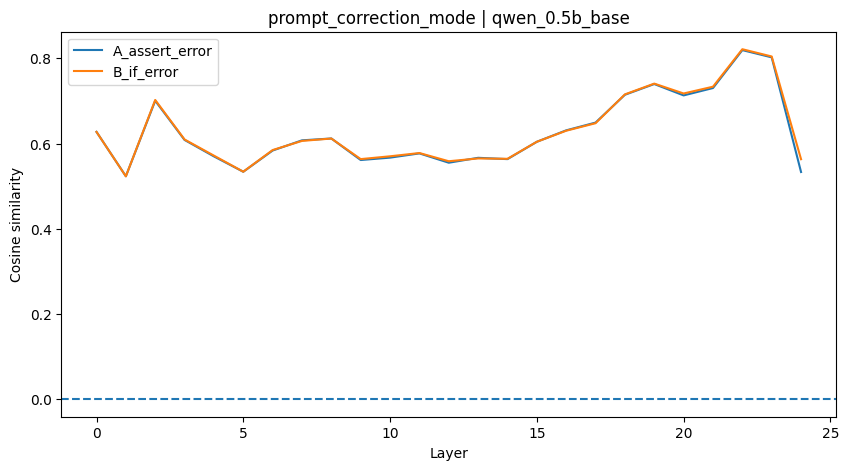

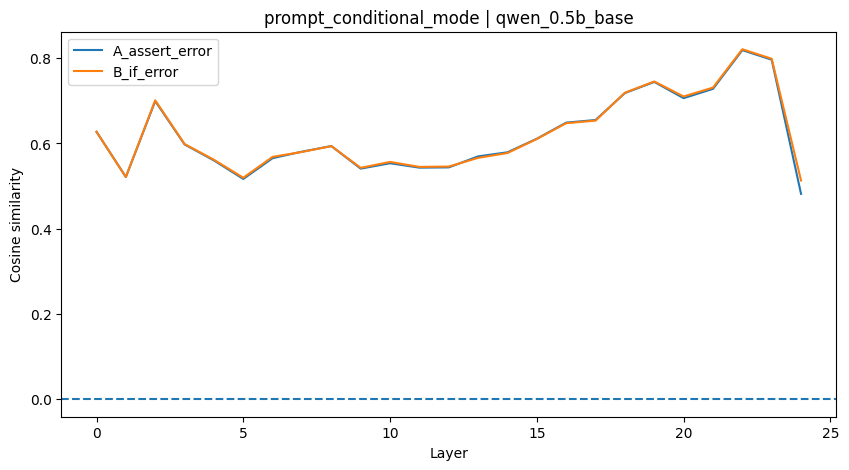

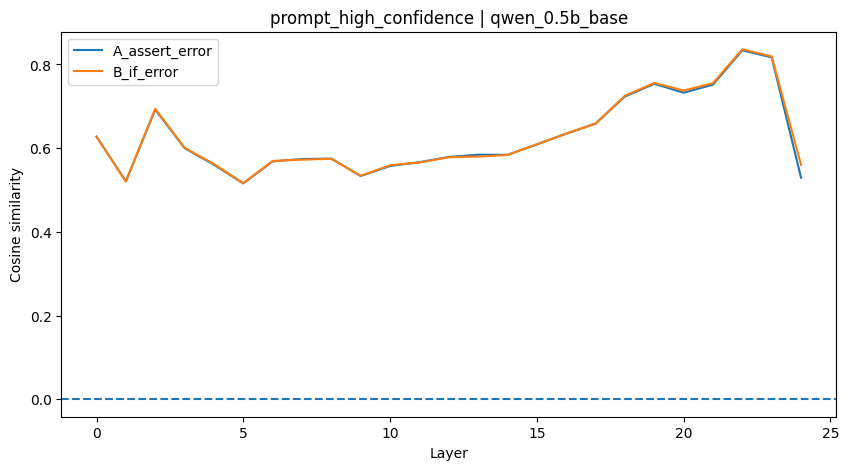

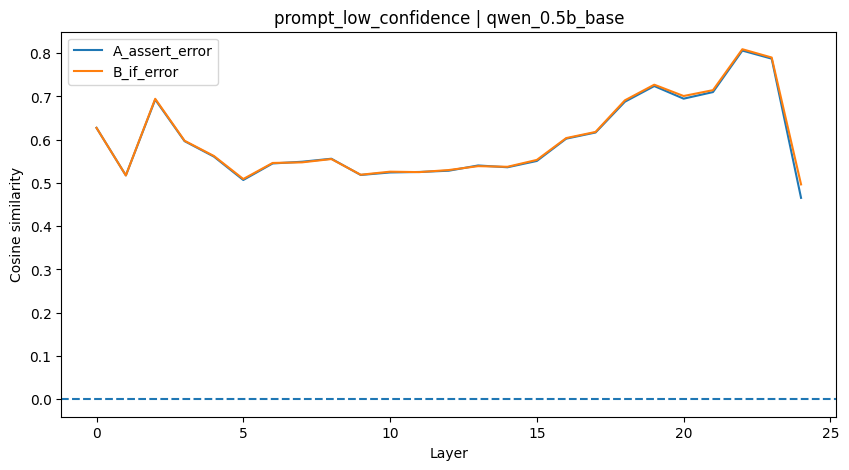

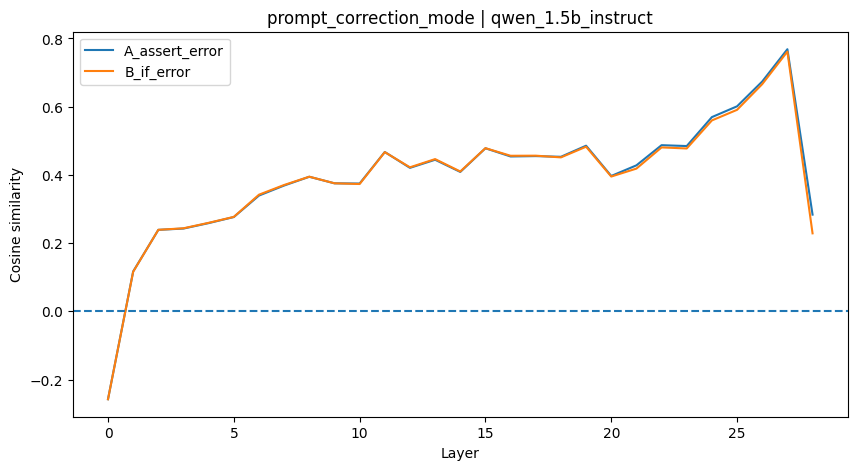

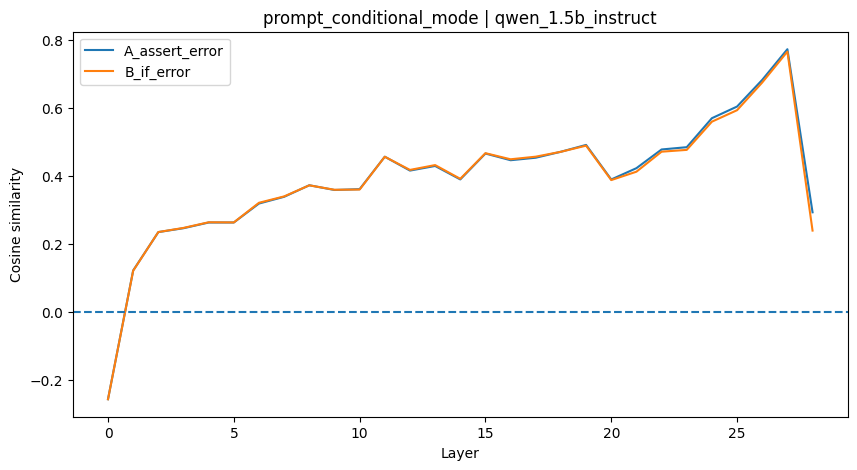

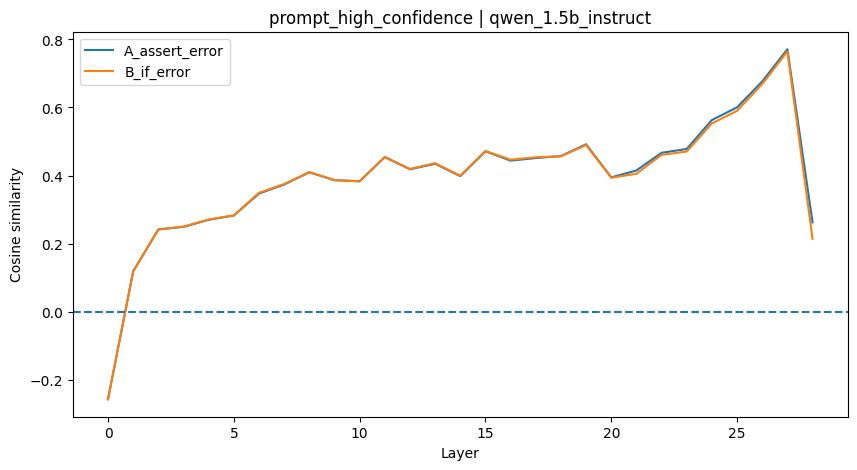

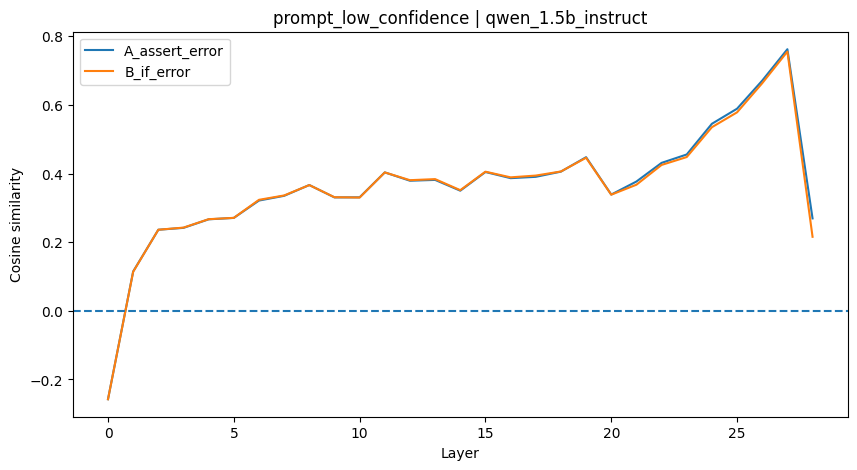

In [16]:
# Cell 16: 層ごとの可視化（prompt 側）
for model_label in df_layers["model_label"].unique():
    sub = df_layers[df_layers["model_label"] == model_label].copy()

    plot_df = (
        sub.groupby(["condition", "layer"])[
            ["prompt_correction_mode", "prompt_conditional_mode", "prompt_high_confidence", "prompt_low_confidence"]
        ]
        .mean()
        .reset_index()
    )

    for metric in ["prompt_correction_mode", "prompt_conditional_mode", "prompt_high_confidence", "prompt_low_confidence"]:
        plt.figure(figsize=(10, 5))
        for cond in sorted(plot_df["condition"].unique()):
            s = plot_df[plot_df["condition"] == cond]
            plt.plot(s["layer"], s[metric], label=cond)
        plt.axhline(0, linestyle="--")
        plt.xlabel("Layer")
        plt.ylabel("Cosine similarity")
        plt.title(f"{metric} | {model_label}")
        plt.legend()
        plt.show()


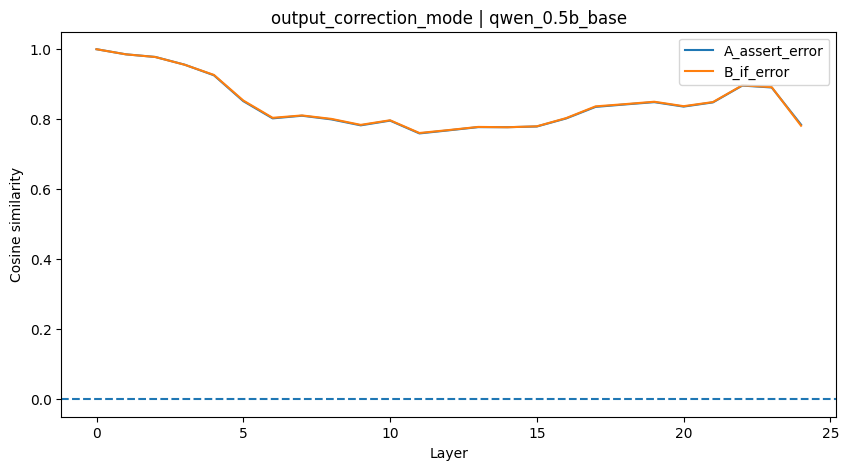

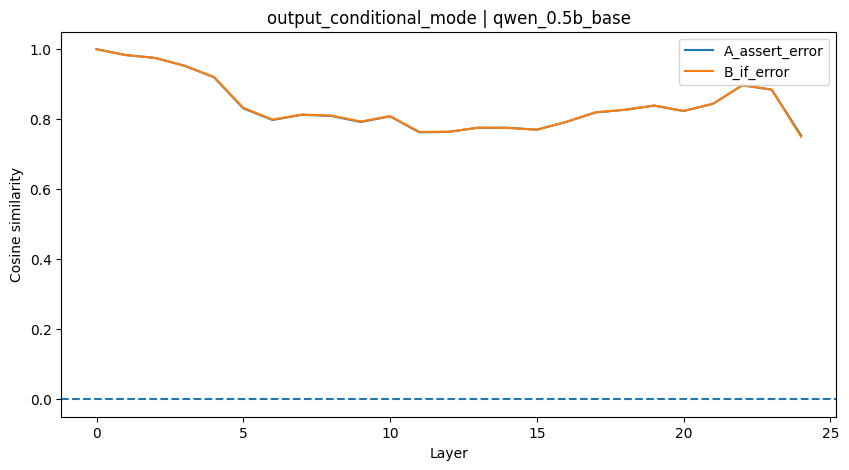

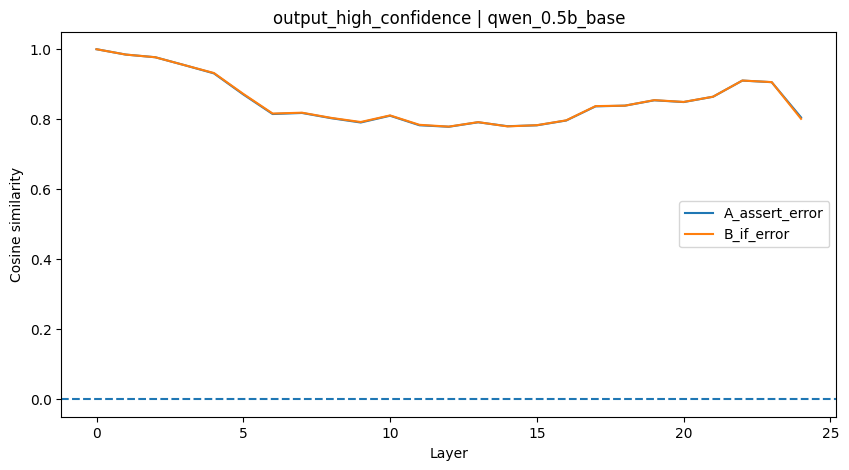

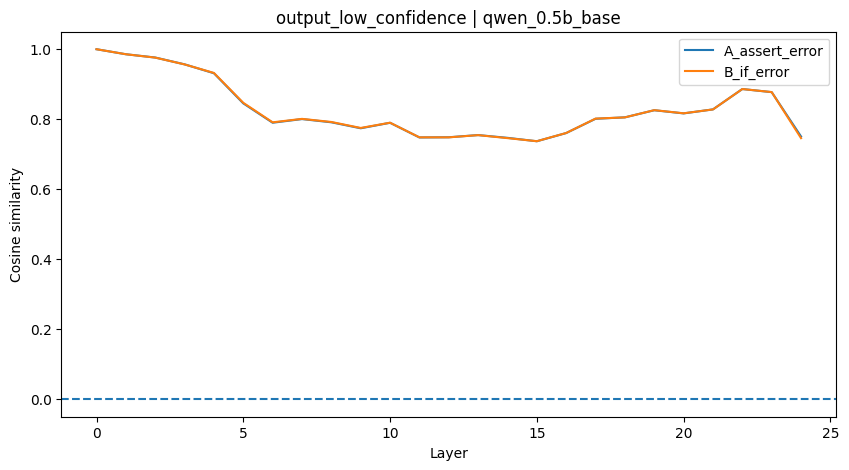

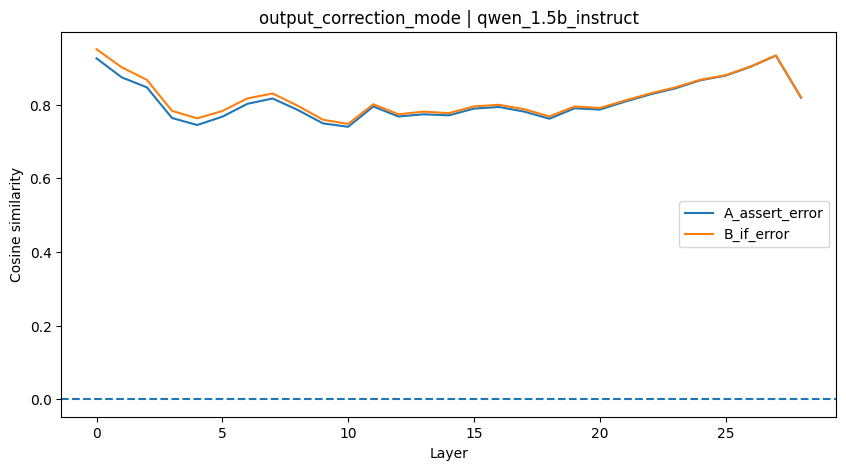

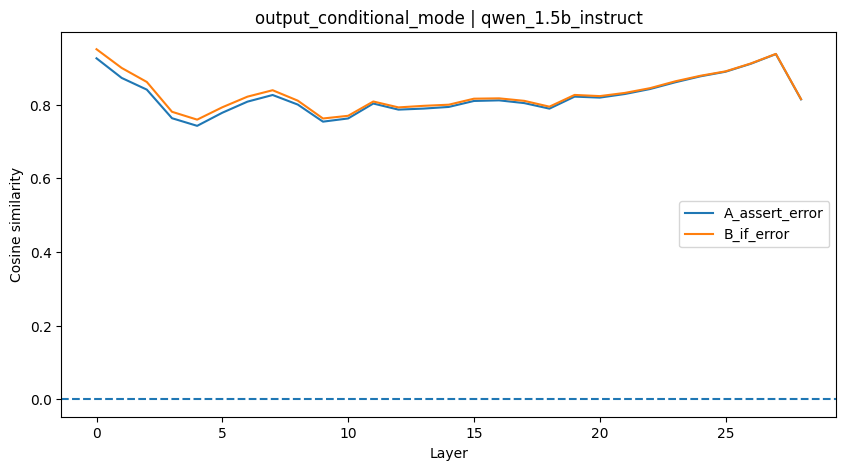

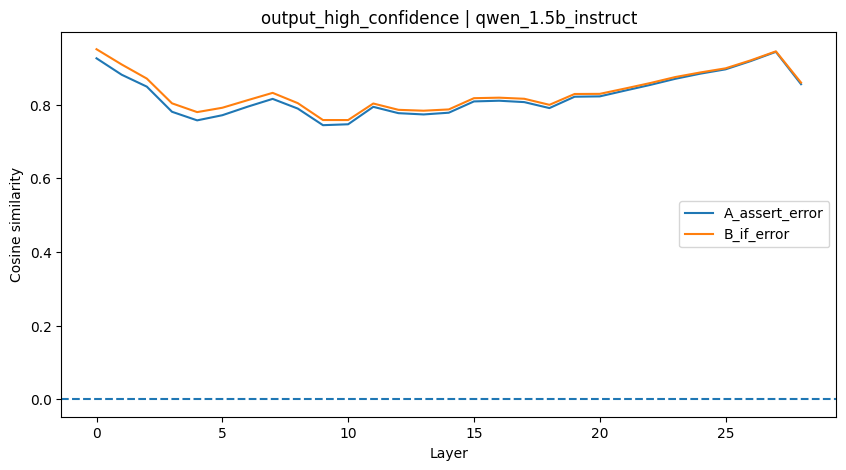

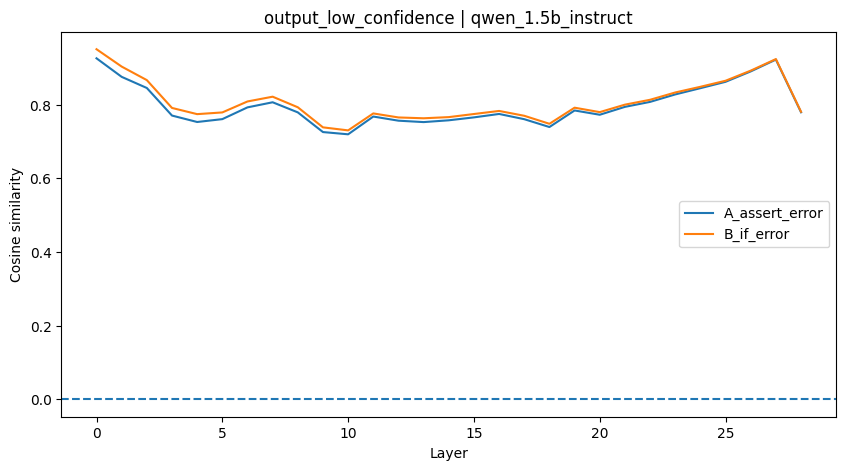

In [17]:
# Cell 17: 層ごとの可視化（output 側）
for model_label in df_layers["model_label"].unique():
    sub = df_layers[df_layers["model_label"] == model_label].copy()

    plot_df = (
        sub.groupby(["condition", "layer"])[
            ["output_correction_mode", "output_conditional_mode", "output_high_confidence", "output_low_confidence"]
        ]
        .mean()
        .reset_index()
    )

    for metric in ["output_correction_mode", "output_conditional_mode", "output_high_confidence", "output_low_confidence"]:
        plt.figure(figsize=(10, 5))
        for cond in sorted(plot_df["condition"].unique()):
            s = plot_df[plot_df["condition"] == cond]
            plt.plot(s["layer"], s[metric], label=cond)
        plt.axhline(0, linestyle="--")
        plt.xlabel("Layer")
        plt.ylabel("Cosine similarity")
        plt.title(f"{metric} | {model_label}")
        plt.legend()
        plt.show()


## 読み取り方の目安

### 出力側
- `corrected_when_needed_rate`  
  誤文に対して正しく修正できた率
- `preserved_when_correct_rate`  
  正文をそのまま維持できた率
- `mean_logprob`  
  生成トークンの平均対数確率。値が高いほど生成時に迷いが少ない傾向
- `hedging_rate`  
  保留的・説明的な表現が出た割合
- `directness_score`  
  修正文だけを返す直接性の近似指標

### 内部表現側
- `prompt_*`  
  **生成前**、つまり指示文を読んだ時点の表現
- `output_*`  
  **生成後**、出力文自体の表現
- `correction_mode` が高い  
  「修正すべき」という方向に寄る
- `conditional_mode` が高い  
  「まず誤り有無を判定してから処理する」方向に寄る
- `high_confidence` / `low_confidence`  
  断定寄りか、保留寄りかの近似

### 予想される観察
- **A** は正文に対しても unnecessary correction を起こしやすい
- **B** は正文保持率が高くなりやすい
- prompt hidden state では  
  - **A**: `correction_mode`, `high_confidence` が相対的に上がる  
  - **B**: `conditional_mode`, `low_confidence` が相対的に上がる  
  という差が出る可能性がある
